In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
import pickle
import matplotlib.pyplot as plt
import numpy as np
from panel_utils import detect_outlier_regions_iqr

In [2]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################

df_clustering = pd.read_excel("Clustering_new.xlsx")


df_clustering["Date"]   = pd.to_datetime(df_clustering["Date"], dayfirst=True, errors="coerce")


cols_clustering = ["Coef_sec", "Salary_def", "Unemp"]
for c in cols_clustering:
    df_clustering[c] = pd.to_numeric(df_clustering[c], errors="coerce")

df_clustering["Year"] = df_clustering["Date"].dt.year

In [5]:
df_clustering.head()

,Region,Date,Coef_sec,Salary_def,Unemp,Year
0,Белгородская область,2019-02-01,1.389572,34632.726672,4.020504,2019
1,Белгородская область,2019-03-01,1.440874,37313.876638,4.078929,2019
2,Белгородская область,2019-04-01,1.342789,38102.127405,4.069884,2019
3,Белгородская область,2019-05-01,1.331648,38466.751931,4.029030,2019
4,Белгородская область,2019-06-01,1.317616,38830.782266,3.934410,2019


In [3]:
print("\n" + "="*70)
print("ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR")
print("="*70)

key_vars = ["Coef_sec", "Salary_def", "Unemp"]
region_quality_iqr = detect_outlier_regions_iqr(df_clustering, key_vars, min_obs=60, max_na_pct=0.3)

print(f"\n АНАЛИЗ {len(region_quality_iqr)} РЕГИОНОВ (IQR)")
print(region_quality_iqr.to_string(index=False))

# СТАТИСТИКА
exclude_count = len(region_quality_iqr[region_quality_iqr['Status'] == 'EXCLUDE'])
keep_count = len(region_quality_iqr) - exclude_count

print(f"\n СТАТИСТИКА:")
print(f"Всего регионов: {len(region_quality_iqr)}")
print(f"Исключено: {exclude_count} ({exclude_count/len(region_quality_iqr)*100:.1f}%)")
print(f"Оставлено: {keep_count}")

# СПИСОК ХОРОШИХ РЕГИОНОВ
good_regions_iqr = region_quality_iqr[region_quality_iqr['Status'] == 'KEEP']['Region'].tolist()

# ФИЛЬТРАЦИЯ ДАННЫХ
df_clustering = df_clustering[df_clustering['Region'].isin(good_regions_iqr)].copy()
print(f"\n Форма после очистки (IQR): {df_clustering.shape}")


ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR

 АНАЛИЗ 80 РЕГИОНОВ (IQR)
                             Region  N_obs NA_pct  IQR_outliers IQR_pct Reasons Status
               Белгородская область     79   0.0%             0    0.0%           KEEP
                   Брянская область     79   0.0%             0    0.0%           KEEP
               Владимирская область     79   0.0%             0    0.0%           KEEP
                Воронежская область     79   0.0%             0    0.0%           KEEP
                 Ивановская область     79   0.0%             0    0.0%           KEEP
                   Тверская область     79   0.0%             0    0.0%           KEEP
                  Калужская область     79   0.0%             0    0.0%           KEEP
                Костромская область     79   0.0%             0    0.0%           KEEP
                    Курская область     79   0.0%             0    0.0%           KEEP
                   Липецкая область     79   0.0%             0    0.0%

In [6]:
# Выбираем за какие годы проводим кластеризацию
df_clustering_recent = df_clustering[df_clustering["Year"].isin([2019, 2020, 2021, 2022, 2023, 2024, 2025])]

df_clustering_year = (
    df_clustering_recent
    .groupby("Region", as_index=False)
    .agg(
        Coef_sec=("Coef_sec", "median"),
        Salary_def=("Salary_def", "median"),
        Unemp=("Unemp", "median"),
    )
)
with open('filter_for_cluster.pkl', 'rb') as f:
    good_regions_iqr = pickle.load(f)

df_clust = df_clustering_year[df_clustering_year["Region"].isin(good_regions_iqr)].dropna().copy()

features = ["Coef_sec", "Salary_def", "Unemp"]
X = df_clust[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
###############################
    #ПОДБОР ЧИСЛА КЛАСТЕРОВ
###############################
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels_k)
    silhouette_scores.append(sil)
    print(f"k={k}: inertia={km.inertia_:.2f}, silhouette={sil:.4f}")

k=2: inertia=137.32, silhouette=0.4314
k=3: inertia=91.89, silhouette=0.4553
k=4: inertia=66.59, silhouette=0.4384
k=5: inertia=54.71, silhouette=0.4084
k=6: inertia=45.20, silhouette=0.3736
k=7: inertia=39.40, silhouette=0.3402
k=8: inertia=34.44, silhouette=0.3358
k=9: inertia=28.62, silhouette=0.3227
k=10: inertia=26.97, silhouette=0.2943


Лучшее k по силуэту: 3


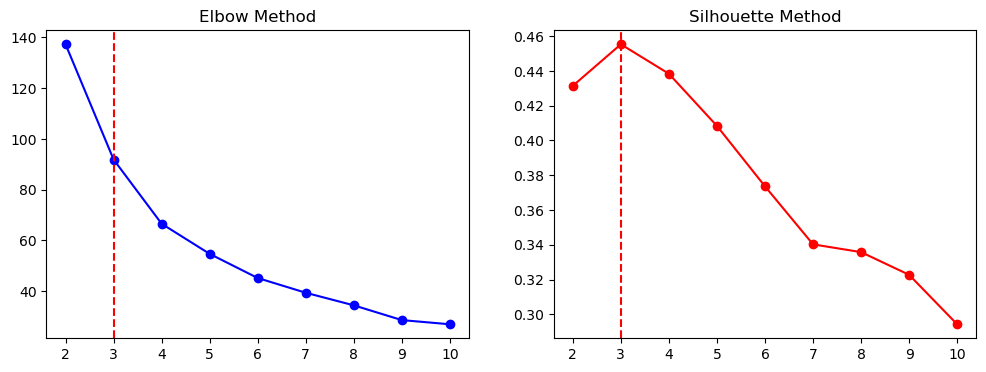

In [8]:
# Лучший k по силуэту
best_k_sil = K_range[np.argmax(silhouette_scores)]
print(f"Лучшее k по силуэту: {best_k_sil}")

# Локоть – более субъективно, но можно взять 3-4
elbow_k = 3  # или по графику

# Графики для интерпретации
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, 'bo-')
ax1.axvline(best_k_sil, color='r', linestyle='--', label=f'best_k_sil={best_k_sil}')
ax1.set_title('Elbow Method')

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.axvline(best_k_sil, color='r', linestyle='--')
ax2.set_title('Silhouette Method')

plt.show()


In [20]:
###############################
    #ФИНАЛЬНАЯ КЛАСТЕРИЗАЦИЯ
###############################

optimal_k = 4 # можно поменять, исходя из вывода выше
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clust["Cluster"] = kmeans.fit_predict(X_scaled) + 1

In [21]:
closest_regions = []

for cl in sorted(df_clust["Cluster"].unique()):
    mask = df_clust["Cluster"] == cl
    points = X_scaled[mask]

    # индекс центроида = номер кластера - 1
    center = kmeans.cluster_centers_[cl - 1]

    dists = np.linalg.norm(points - center, axis=1)
    idx_min = dists.argmin()

    row_closest = df_clust[mask].iloc[idx_min]
    closest_regions.append(row_closest)

closest_df = pd.DataFrame(closest_regions)
print(closest_df[["Cluster", "Region", "Coef_sec", "Salary_def", "Unemp"]])


    Cluster                 Region  Coef_sec    Salary_def     Unemp
41        1      Республика Адыгея  1.537411  43900.770043  8.023607
7         2  Волгоградская область  1.288572  45975.992610  3.782166
30        3     Мурманская область  0.735616  72120.134101  4.444872
29        4     Московская область  1.596805  62633.801503  2.854303


In [22]:
cluster_summary_hank = df_clust.groupby("Cluster").agg({
    "Coef_sec": ["mean", "median"],
    "Salary_def": ["mean", "median"], 
    "Unemp": ["mean", "median"],
}).round(2).reset_index()


print("Характеристики кластеров:")
print(cluster_summary_hank.to_string(index=False))



Характеристики кластеров:
Cluster Coef_sec        Salary_def          Unemp       
            mean median       mean   median  mean median
      1     1.47   1.49   47407.46 43900.77  8.14   8.02
      2     1.33   1.31   48894.99 49224.24  3.83   3.67
      3     0.94   1.01   76757.55 74506.71  4.10   4.30
      4     1.76   1.75   62688.30 58299.96  2.74   2.85


In [23]:
# Список регионов по HANK-кластерам
hank_clusters_regions = (
    df_clust
    .sort_values(["Cluster", "Region"])
    .groupby("Cluster")["Region"]
    .apply(list)
    .reset_index(name="Regions")
)

print("=== КЛАСТЕРЫ ===")
for _, row in hank_clusters_regions.iterrows():
    cluster_id = row["Cluster"]
    regions = row["Regions"]
    n_regions = len(regions)
    
    print(f"\n Кластер {cluster_id} ({n_regions} регионов):")
    for r in sorted(regions):  # алфавитный порядок
        print(f"  {r}")
    print("-" * 50)


=== КЛАСТЕРЫ ===

 Кластер 1 (7 регионов):
  Астраханская область
  Забайкальский край
  Курганская область
  Республика Адыгея
  Республика Алтай
  Республика Бурятия
  Республика Калмыкия
--------------------------------------------------

 Кластер 2 (42 регионов):
  Алтайский край
  Амурская область
  Архангельская область
  Белгородская область
  Брянская область
  Владимирская область
  Волгоградская область
  Вологодская область
  Воронежская область
  Ивановская область
  Калининградская область
  Калужская область
  Костромская область
  Курская область
  Липецкая область
  Нижегородская область
  Новгородская область
  Новосибирская область
  Омская область
  Оренбургская область
  Орловская область
  Пензенская область
  Пермский край
  Псковская область
  Республика Башкортостан
  Республика Карелия
  Республика Марий Эл
  Республика Мордовия
  Республика Хакасия
  Ростовская область
  Самарская область
  Свердловская область
  Смоленская область
  Ставропольский край
  Твер

In [24]:
region_cluster = df_clust[['Region', 'Cluster']].copy()
region_cluster.head()

,Region,Cluster
0,Алтайский край,2
1,Амурская область,2
2,Архангельская область,2
3,Астраханская область,1
4,Белгородская область,2


In [12]:
#region_cluster.to_excel('region_cluster.xlsx')

In [25]:
cluster_dummies = pd.get_dummies(region_cluster['Cluster'],prefix='Cluster_new').astype(int)

region_cluster = pd.concat([region_cluster, cluster_dummies], axis=1)

region_cluster = region_cluster.drop(columns=['Cluster','Cluster_new_4'])

region_cluster.head()

,Region,Cluster_new_1,Cluster_new_2,Cluster_new_3
0,Алтайский край,0,1,0
1,Амурская область,0,1,0
2,Архангельская область,0,1,0
3,Астраханская область,1,0,0
4,Белгородская область,0,1,0


In [26]:
pickle_filename = 'region_cluster_new_dataset.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(region_cluster, f)